In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load your clean processed file
df = pd.read_csv('../data/processed/lending_club_clean.csv', low_memory=False)

# Set a clean visual style for all charts
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Make sure output folder exists
os.makedirs('../outputs/charts', exist_ok=True)

print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
print(f"\nColumns: {list(df.columns)}")

Rows: 765,050
Columns: 26

Columns: ['loan_amnt', 'funded_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'purpose', 'addr_state', 'dti', 'earliest_cr_line', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_pymnt', 'total_rec_prncp', 'total_rec_int', 'last_pymnt_d', 'recoveries']


In [2]:
# See basic statistics of every numeric column
print("Dataset Snapshot:\n")
print(df.describe().round(2).to_string())

Dataset Snapshot:

       loan_amnt  funded_amnt       term   int_rate  installment  emp_length  annual_inc        dti   open_acc    pub_rec  revol_bal  revol_util  total_pymnt  total_rec_prncp  total_rec_int  recoveries
count  765050.00    765050.00  765050.00  765050.00    765050.00   765050.00   765050.00  765050.00  765050.00  765050.00  765050.00   765050.00    765050.00        765050.00      765050.00   765050.00
mean    13425.85     13425.85      42.48      13.06       399.75        5.71    65261.91      18.12      10.95       0.18   10887.52       43.88      6671.56          5133.20        1490.10       47.30
std      8242.04      8242.04      10.65       5.16       239.65        3.59    28287.25       8.74       5.54       0.50    7697.49       24.42      6400.38          5726.31        1597.71      387.42
min      1000.00      1000.00      36.00       5.31         7.61        0.00        0.00       0.00       0.00       0.00       0.00        0.00         0.00             0.0

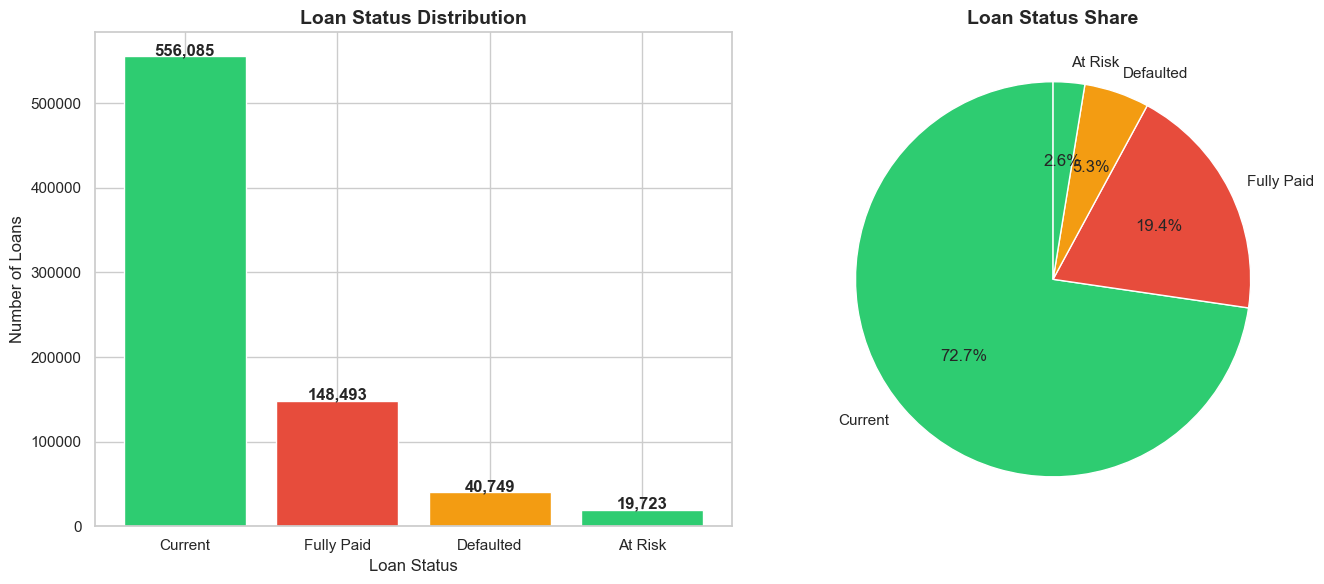

Chart saved ✅


In [3]:
# Business question: How many loans paid vs defaulted vs at risk?

status_counts = df['loan_status'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#f39c12']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart
axes[0].bar(status_counts.index, status_counts.values, color=colors)
axes[0].set_title('Loan Status Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Loan Status')
axes[0].set_ylabel('Number of Loans')
for i, v in enumerate(status_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(
    status_counts.values,
    labels=status_counts.index,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Loan Status Share', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/charts/01_loan_status.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved ✅")

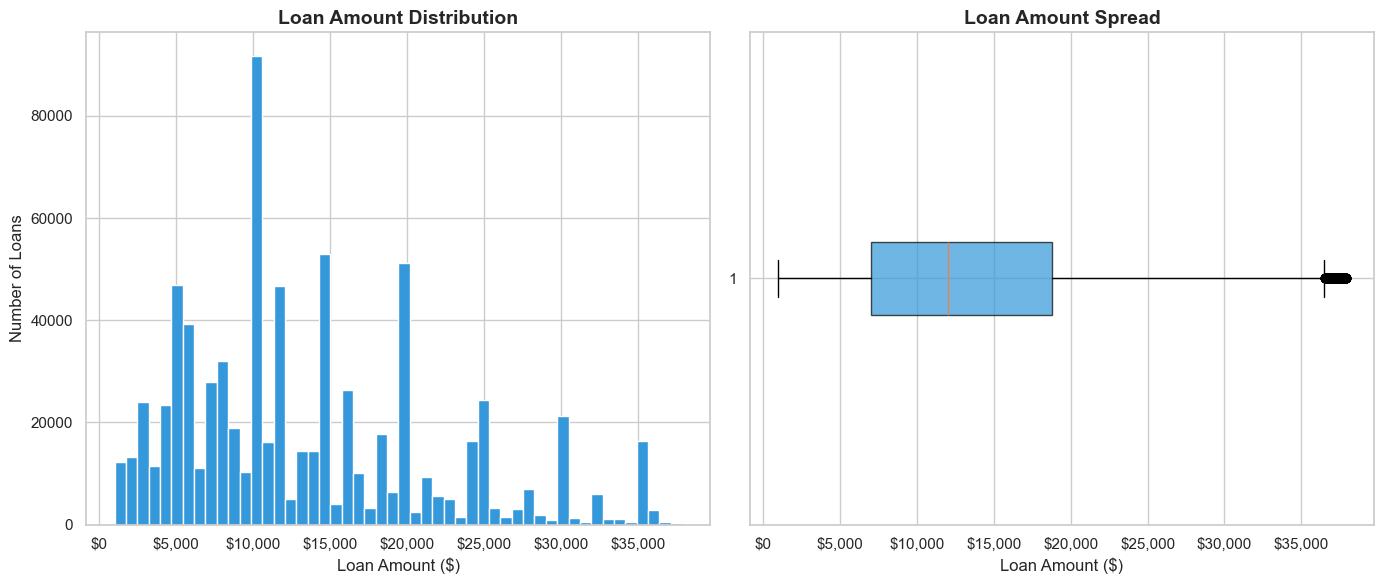

Chart saved ✅


In [4]:
# Business question: How much are people typically borrowing?

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogram
axes[0].hist(df['loan_amnt'], bins=50, color='#3498db', edgecolor='white')
axes[0].set_title('Loan Amount Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Loan Amount ($)')
axes[0].set_ylabel('Number of Loans')
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x:,.0f}')
)

# Box plot
axes[1].boxplot(df['loan_amnt'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.7))
axes[1].set_title('Loan Amount Spread', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Loan Amount ($)')
axes[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x:,.0f}')
)

plt.tight_layout()
plt.savefig('../outputs/charts/02_loan_amount.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved ✅")

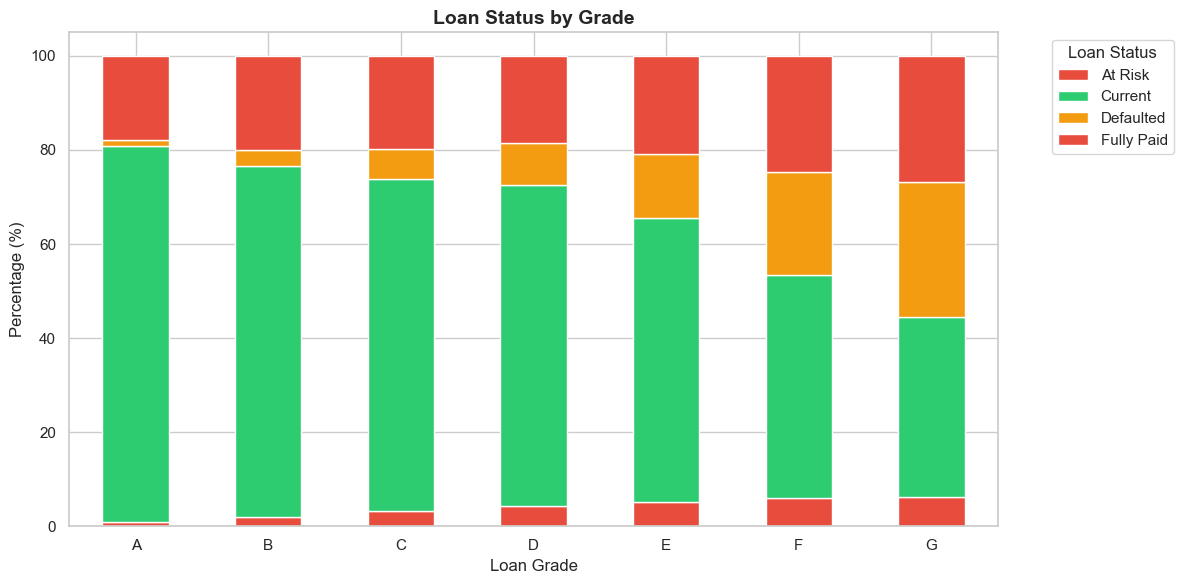

Chart saved ✅


In [5]:
# Business question: Which loan grades default the most?

grade_status = df.groupby(['grade', 'loan_status']).size().unstack(fill_value=0)
grade_status_pct = grade_status.div(grade_status.sum(axis=1), axis=0) * 100
grade_status_pct = grade_status_pct.sort_index()

colors = ['#e74c3c', '#2ecc71', '#f39c12']
grade_status_pct.plot(
    kind='bar',
    stacked=True,
    color=colors,
    figsize=(12, 6),
    edgecolor='white'
)

plt.title('Loan Status by Grade', fontsize=14, fontweight='bold')
plt.xlabel('Loan Grade')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Loan Status', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('../outputs/charts/03_default_by_grade.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved ✅")

C:\Users\vakul\AppData\Local\Temp\ipykernel_11788\2355573710.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


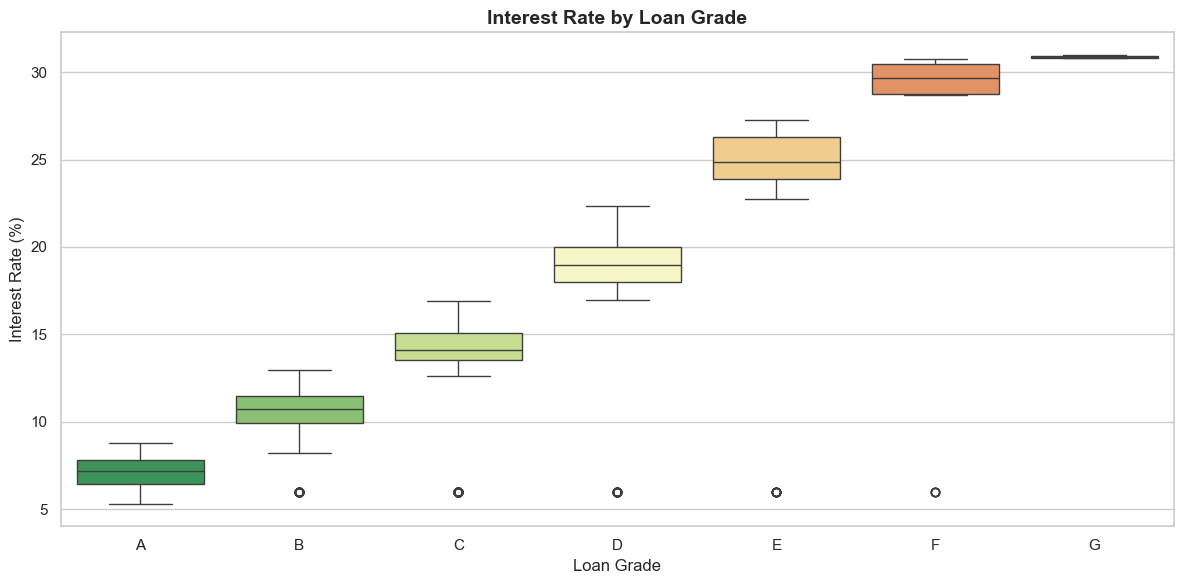

Chart saved ✅


In [6]:
# Business question: How do interest rates vary across loan grades?

grade_order = sorted(df['grade'].dropna().unique())

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,
    x='grade',
    y='int_rate',
    order=grade_order,
    palette='RdYlGn_r'
)
plt.title('Interest Rate by Loan Grade', fontsize=14, fontweight='bold')
plt.xlabel('Loan Grade')
plt.ylabel('Interest Rate (%)')
plt.tight_layout()
plt.savefig('../outputs/charts/04_interest_by_grade.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved ✅")

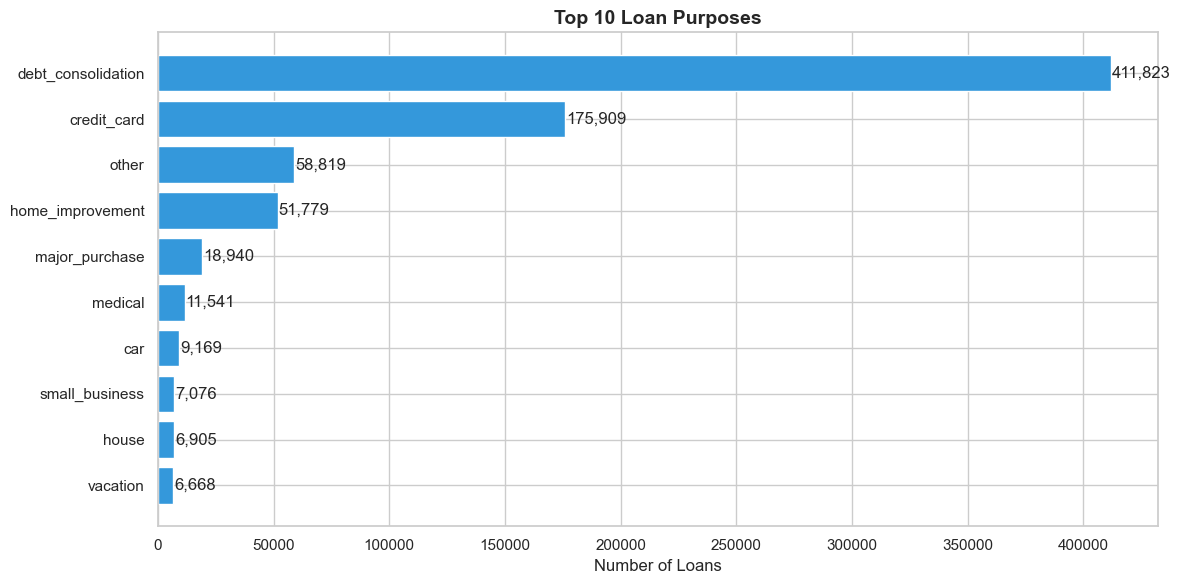

Chart saved ✅


In [7]:
# Business question: Why are people borrowing money?

purpose_counts = df['purpose'].value_counts().head(10)

plt.figure(figsize=(12, 6))
bars = plt.barh(
    purpose_counts.index[::-1],
    purpose_counts.values[::-1],
    color='#3498db',
    edgecolor='white'
)
plt.title('Top 10 Loan Purposes', fontsize=14, fontweight='bold')
plt.xlabel('Number of Loans')
for bar, val in zip(bars, purpose_counts.values[::-1]):
    plt.text(
        bar.get_width() + 500,
        bar.get_y() + bar.get_height()/2,
        f'{val:,}',
        va='center'
    )
plt.tight_layout()
plt.savefig('../outputs/charts/05_loan_purpose.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved ✅")

In [8]:
# Business question: Do higher earners borrow more?

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df.sample(5000),  # sample 5000 so chart isn't overcrowded
    x='annual_inc',
    y='loan_amnt',
    hue='loan_status',
    alpha=0.5,
    palette={'Fully Paid': '#2ecc71',
             'Defaulted': '#e74c3c',
             'At Risk': '#f39c12'}
)
plt.title('Annual Income vs Loan Amount', fontsize=14, fontweight='bold')
plt.xlabel('Annual Income ($)')
plt.ylabel('Loan Amount ($)')
plt.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x:,.0f}')
)
plt.tight_layout()
plt.savefig('../outputs/charts/06_income_vs_loan.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved ✅")

ValueError: The palette dictionary is missing keys: {'Current'}

<Figure size 1200x600 with 0 Axes>

ValueError: The palette dictionary is missing keys: {'Current'}

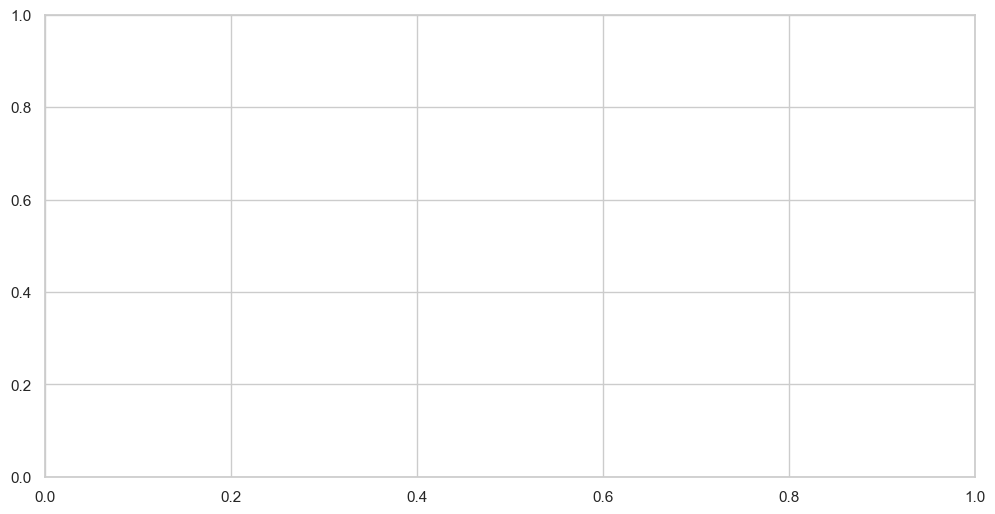

In [9]:
# Business question: Do higher earners borrow more?

fig, ax = plt.subplots(figsize=(12, 6))

sns.scatterplot(
    data=df.sample(5000),
    x='annual_inc',
    y='loan_amnt',
    hue='loan_status',
    alpha=0.5,
    palette={
        'Fully Paid': '#2ecc71',
        'Defaulted': '#e74c3c',
        'At Risk': '#f39c12'
    },
    ax=ax
)

ax.set_title('Annual Income vs Loan Amount', fontsize=14, fontweight='bold')
ax.set_xlabel('Annual Income ($)')
ax.set_ylabel('Loan Amount ($)')
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x:,.0f}')
)

plt.tight_layout()
plt.savefig('../outputs/charts/06_income_vs_loan.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved ✅")

Loan status values: <StringArray>
['Current', 'Fully Paid', 'At Risk', 'Defaulted']
Length: 4, dtype: str


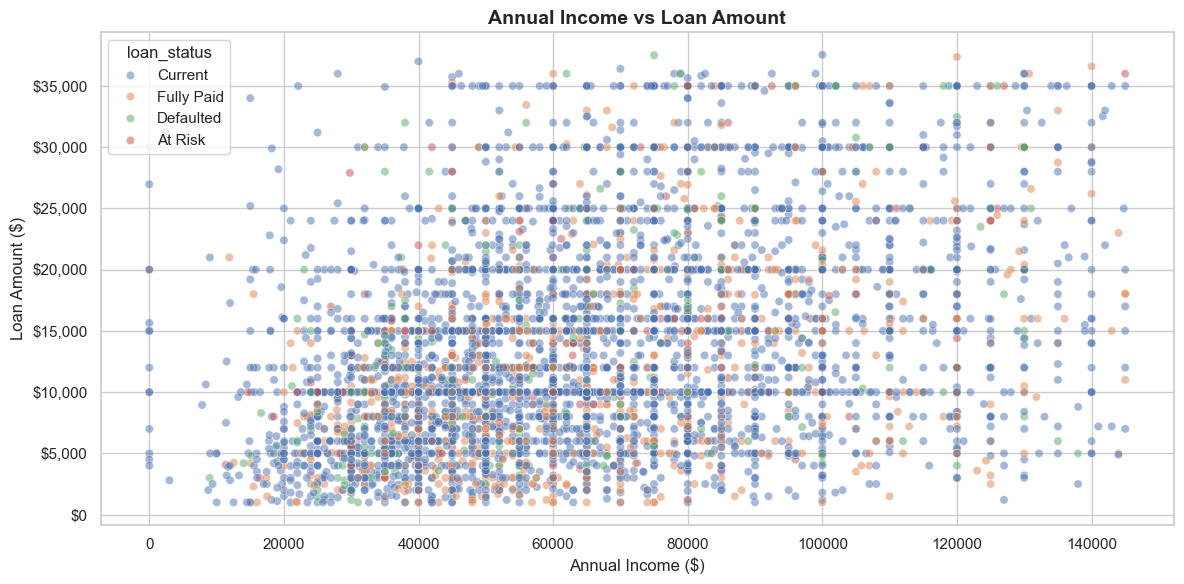

In [10]:
# Business question: Do higher earners borrow more?

# Check exact loan_status values first
print("Loan status values:", df['loan_status'].unique())

fig, ax = plt.subplots(figsize=(12, 6))

sns.scatterplot(
    data=df.sample(5000, random_state=42),
    x='annual_inc',
    y='loan_amnt',
    hue='loan_status',
    alpha=0.5,
    ax=ax
)

ax.set_title('Annual Income vs Loan Amount', fontsize=14, fontweight='bold')
ax.set_xlabel('Annual Income ($)')
ax.set_ylabel('Loan Amount ($)')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x:,.0f}')
)

plt.tight_layout()
plt.savefig('../outputs/charts/06_income_vs_loan.png', dpi=150, bbox_inches='tight')

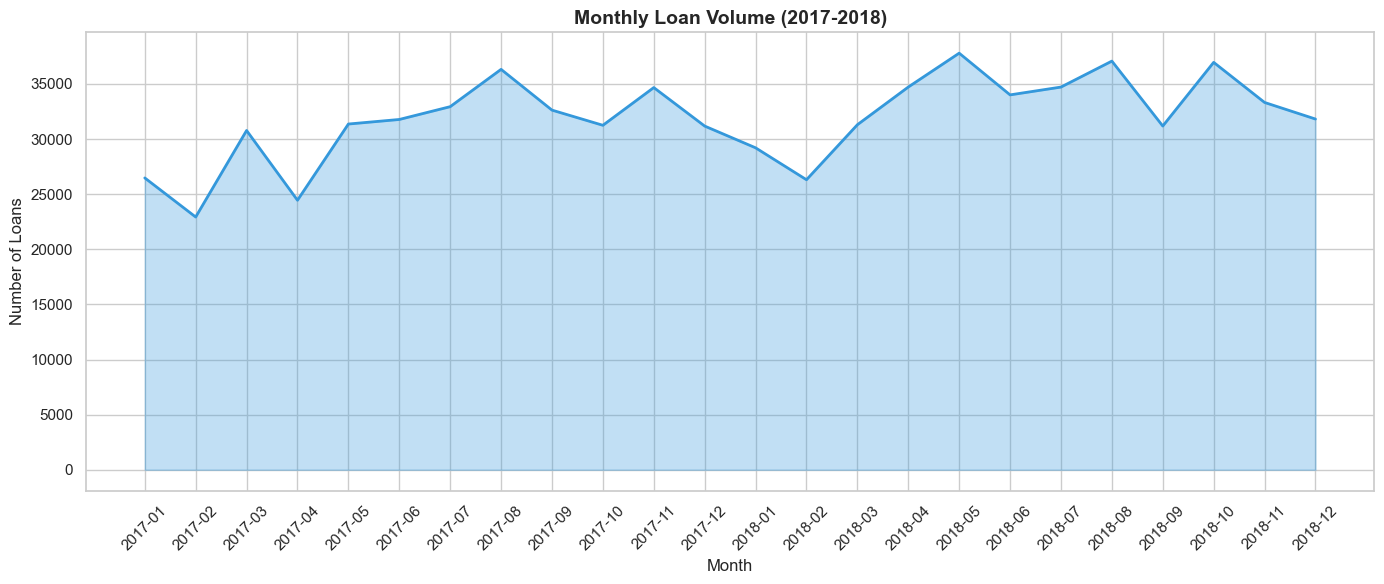

Chart saved ✅


In [11]:
# Business question: How did lending volume change over time?

df['issue_d'] = pd.to_datetime(df['issue_d'])
monthly = df.groupby(df['issue_d'].dt.to_period('M')).size()
monthly.index = monthly.index.astype(str)

plt.figure(figsize=(14, 6))
plt.plot(monthly.index, monthly.values, color='#3498db', linewidth=2)
plt.fill_between(monthly.index, monthly.values, alpha=0.3, color='#3498db')
plt.title('Monthly Loan Volume (2017-2018)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Loans')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/charts/07_monthly_volume.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved ✅")

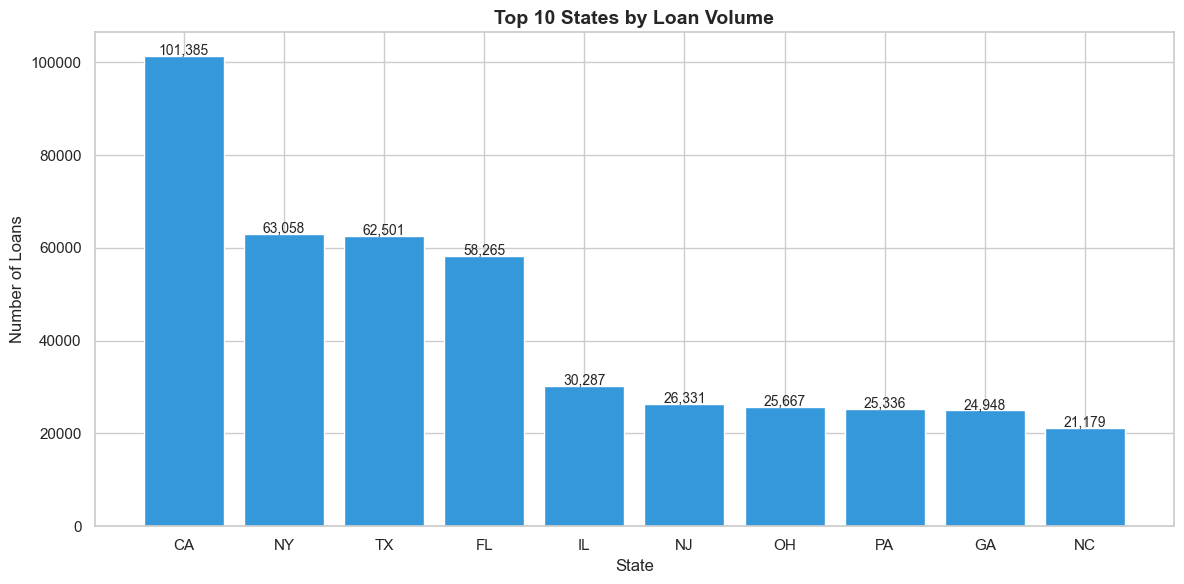

Chart saved ✅


In [12]:
# Business question: Which states borrow the most?

state_counts = df['addr_state'].value_counts().head(10)

plt.figure(figsize=(12, 6))
bars = plt.bar(
    state_counts.index,
    state_counts.values,
    color='#3498db',
    edgecolor='white'
)
plt.title('Top 10 States by Loan Volume', fontsize=14, fontweight='bold')
plt.xlabel('State')
plt.ylabel('Number of Loans')
for bar, val in zip(bars, state_counts.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 200,
        f'{val:,}',
        ha='center',
        fontsize=10
    )
plt.tight_layout()
plt.savefig('../outputs/charts/08_top_states.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved ✅")

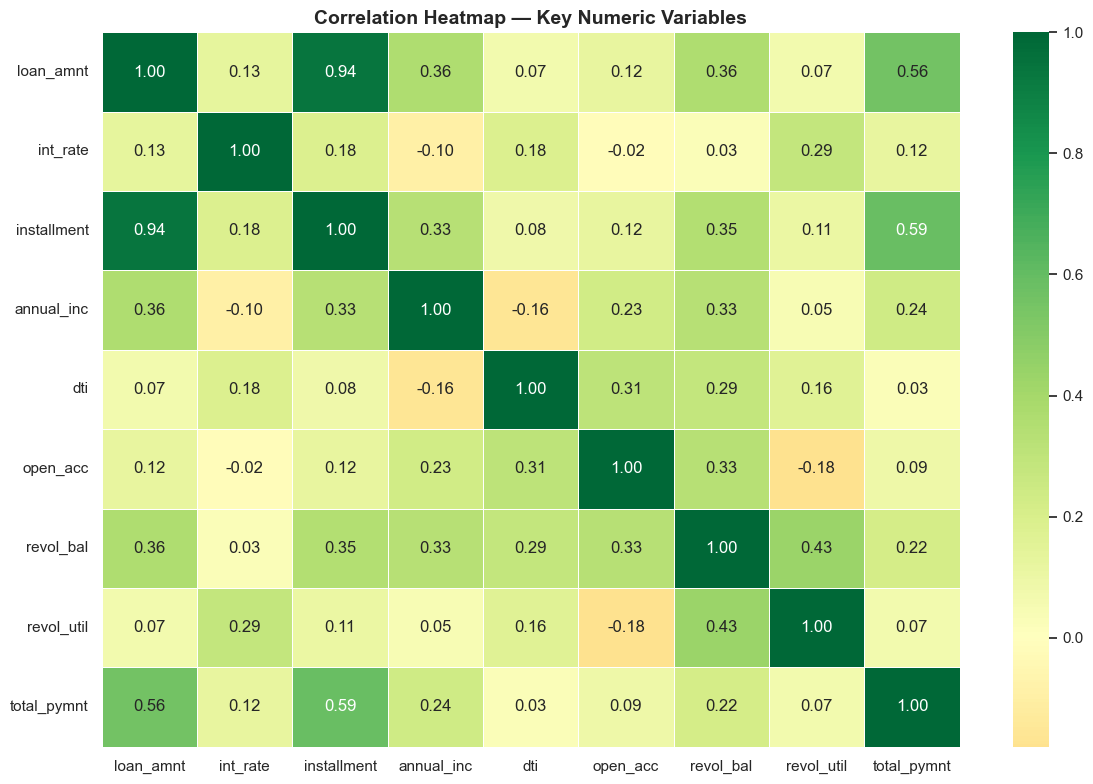

Chart saved ✅


In [13]:
# Business question: Which numeric factors are most related to each other?

numeric_cols = [
    'loan_amnt', 'int_rate', 'installment',
    'annual_inc', 'dti', 'open_acc',
    'revol_bal', 'revol_util', 'total_pymnt'
]

corr = df[numeric_cols].corr().round(2)

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    annot=True,
    cmap='RdYlGn',
    center=0,
    fmt='.2f',
    linewidths=0.5
)
plt.title('Correlation Heatmap — Key Numeric Variables',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/charts/09_correlation_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved ✅")